In [ ]:
pip install ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
dataset_path = "/content/drive/MyDrive/signature_detection_dataset"
print(os.listdir(dataset_path))

['testimg.jpg', 'testimg2.jpg', '33122531_1.jpg', 'test4.jpg', 'Copy of testimg.jpg', 'signature_yolo.zip', 'signature_snn.zip']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip"))

['signature_yolo']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo"))

['images', 'labels']


In [ ]:
import os
base = "/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo"
for root, dirs, files in os.walk(base):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-"*50)

/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo
Folders: ['images', 'labels']
Files: []
--------------------------------------------------
/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo/images
Folders: ['train', 'val']
Files: []
--------------------------------------------------
/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo/images/train
Folders: []
Files: ['743.jpg', '748.jpg', '741.jpg', '727.jpg', '721.jpg']
--------------------------------------------------
/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo/images/val
Folders: []
Files: ['2.jpg', '5.jpg', '13.jpg', '17.jpg', '9.jpg']
--------------------------------------------------
/content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo/labels
Folders: ['train', 'val']
Files: ['train.cache', 'val.cache']
--------------------------------------------------
/c

In [ ]:
data_yaml = """
path: /content/drive/MyDrive/signature_detection_dataset/signature_yolo.zip/signature_yolo
train: images/train
val: images/val
nc: 1
names:
  0: signature
"""
with open("/content/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created!")

data.yaml created!


In [ ]:
from ultralytics import YOLO
model = YOLO("yolo26n.pt")
print("Model loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully!


In [ ]:
from ultralytics import YOLO
model = YOLO("yolo26n.pt")
results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="signature_detector"
)

Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=signature_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/signature_detector/weights/best.pt")

results = model.predict(
    source="/content/drive/MyDrive/signature_detection_dataset/testimg.jpg",
    save=True,
    conf=0.25
)


image 1/1 /content/drive/MyDrive/signature_detection_dataset/testimg.jpg: 448x640 1 signature, 90.5ms
Speed: 3.4ms preprocess, 90.5ms inference, 4.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


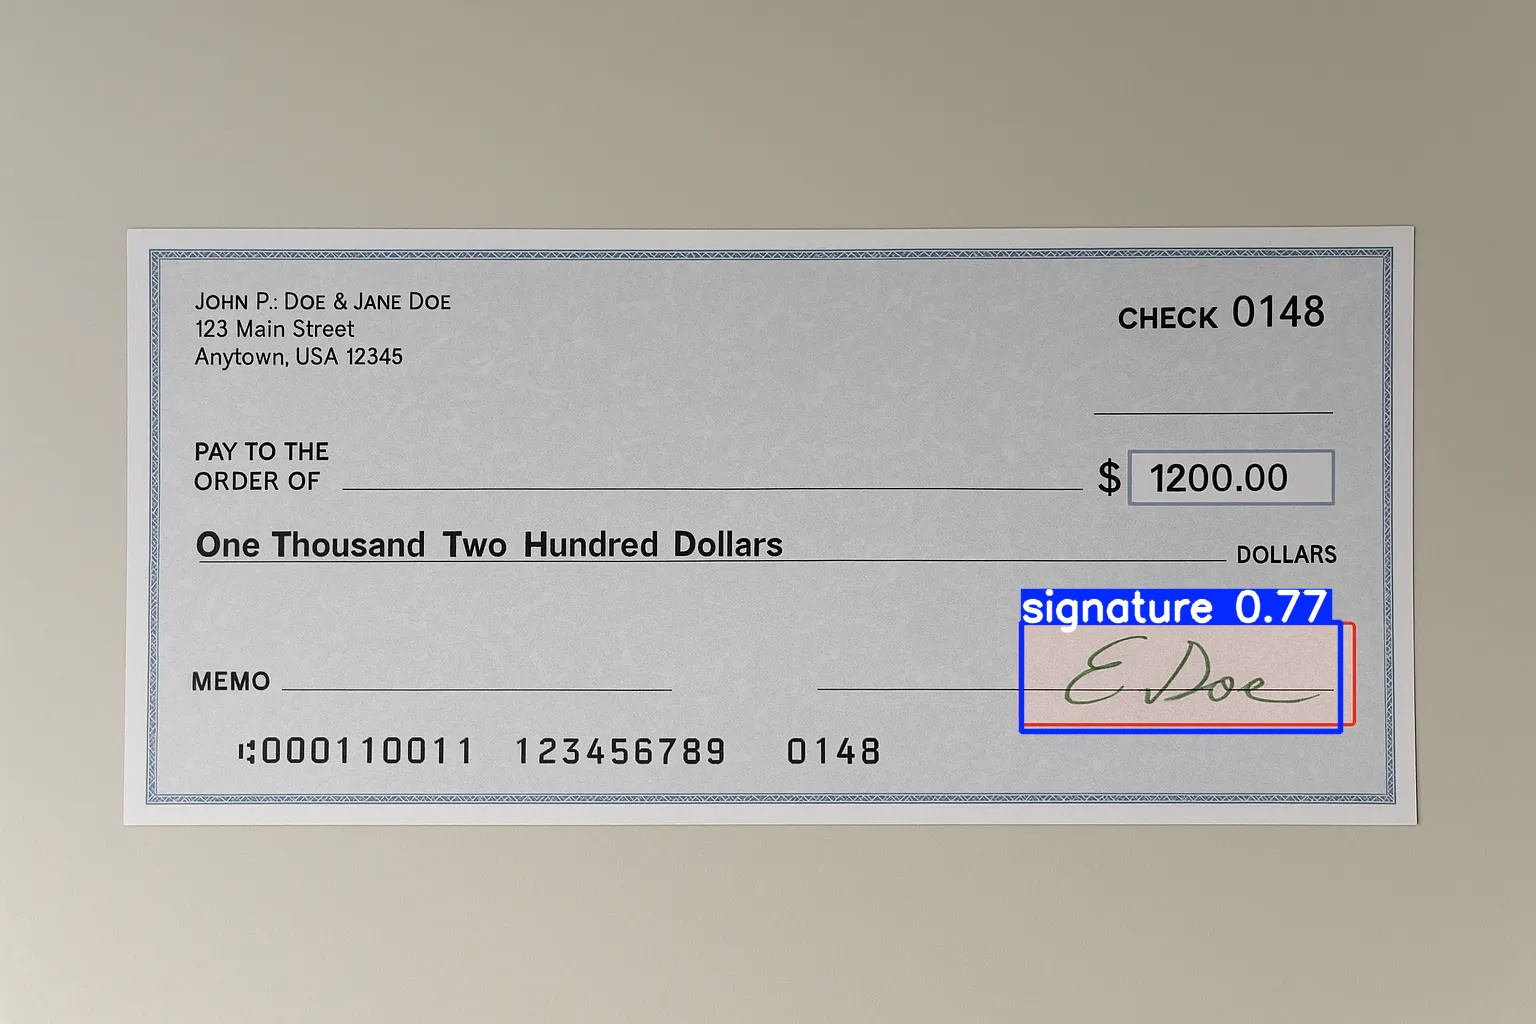

In [ ]:
from IPython.display import Image, display

saved_path = "/content/runs/detect/predict/testimg.jpg"

display(Image(filename=saved_path))

In [ ]:
import shutil

shutil.copy(
    "/content/runs/detect/signature_detector/weights/best.pt",
    "/content/drive/MyDrive/signature_yolo_best.pt"
)

print("YOLO model saved successfully!")

YOLO model saved successfully!


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/signature_yolo_best.pt"))

True
